# 02 Preprocessing and Window Segmentation

In this notebook, we preprocess the WESAD dataset and convert continuous physiological signals into fixed-size time windows.

We use chest signals first because ECG, EDA, respiration, temperature, and labels are all sampled at the same frequency.

The output of this notebook will be windowed data that can later be used for feature extraction and machine learning.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "WESAD"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data folder:", RAW_DATA_DIR)
print("Processed data folder:", PROCESSED_DATA_DIR)
print("Results folder:", RESULTS_DIR)

print("Raw data exists:", RAW_DATA_DIR.exists())

Raw data folder: ..\data\WESAD
Processed data folder: ..\data\processed
Results folder: ..\results
Raw data exists: True


In [3]:
LABEL_NAMES = {
    0: "Undefined / Transition",
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

TARGET_LABELS = [1, 2, 3]

for label_id, label_name in LABEL_NAMES.items():
    print(label_id, "=", label_name)

0 = Undefined / Transition
1 = Neutral / Baseline
2 = Stress
3 = Amusement
4 = Meditation


In [4]:
FS_CHEST = 700

WINDOW_SIZE_SEC = 30
OVERLAP = 0.50

WINDOW_SIZE_SAMPLES = WINDOW_SIZE_SEC * FS_CHEST
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - OVERLAP))

SIGNAL_NAMES = ["ECG", "EDA", "Resp", "Temp"]

print("Sampling rate:", FS_CHEST, "Hz")
print("Window size:", WINDOW_SIZE_SEC, "seconds")
print("Window size in samples:", WINDOW_SIZE_SAMPLES)
print("Step size in samples:", STEP_SIZE_SAMPLES)
print("Signals used:", SIGNAL_NAMES)

Sampling rate: 700 Hz
Window size: 30 seconds
Window size in samples: 21000
Step size in samples: 10500
Signals used: ['ECG', 'EDA', 'Resp', 'Temp']


In [5]:
subject_folders = sorted([folder for folder in RAW_DATA_DIR.iterdir() if folder.is_dir()])

print("Number of subject folders:", len(subject_folders))

for folder in subject_folders:
    print(folder.name)

Number of subject folders: 15
S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9


In [6]:
def load_subject_data(subject_id, raw_data_dir):
    """
    Load one WESAD subject file.

    Parameters
    ----------
    subject_id : str
        Subject ID, for example "S2".
    raw_data_dir : Path
        Path to the WESAD dataset folder.

    Returns
    -------
    dict
        Loaded subject data.
    """
    subject_file = raw_data_dir / subject_id / f"{subject_id}.pkl"
    
    with open(subject_file, "rb") as file:
        subject_data = pickle.load(file, encoding="latin1")
    
    return subject_data

In [7]:
test_subject_id = "S2"

test_data = load_subject_data(test_subject_id, RAW_DATA_DIR)

print("Loaded subject:", test_data["subject"])
print("Main keys:", test_data.keys())
print("Signal keys:", test_data["signal"].keys())
print("Chest signal keys:", test_data["signal"]["chest"].keys())
print("Label shape:", test_data["label"].shape)

Loaded subject: S2
Main keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Chest signal keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
Label shape: (4255300,)


In [8]:
def extract_chest_signals(subject_data, signal_names):
    """
    Extract selected chest signals and combine them into one array.

    Parameters
    ----------
    subject_data : dict
        Loaded WESAD subject data.
    signal_names : list
        List of chest signal names to extract.

    Returns
    -------
    np.ndarray
        Signal array with shape: samples x channels.
    """
    chest_data = subject_data["signal"]["chest"]
    
    signal_list = []
    
    for signal_name in signal_names:
        signal_values = chest_data[signal_name].reshape(-1)
        signal_list.append(signal_values)
    
    combined_signals = np.stack(signal_list, axis=1)
    
    return combined_signals

In [9]:
test_signals = extract_chest_signals(test_data, SIGNAL_NAMES)
test_labels = test_data["label"].reshape(-1)

print("Signal shape:", test_signals.shape)
print("Label shape:", test_labels.shape)

print("Number of signal samples:", test_signals.shape[0])
print("Number of label samples:", test_labels.shape[0])
print("Number of channels:", test_signals.shape[1])

Signal shape: (4255300, 4)
Label shape: (4255300,)
Number of signal samples: 4255300
Number of label samples: 4255300
Number of channels: 4


In [10]:
unique_labels, counts = np.unique(test_labels, return_counts=True)

label_distribution = pd.DataFrame({
    "label": unique_labels,
    "count": counts
})

label_distribution["label_name"] = label_distribution["label"].map(LABEL_NAMES)

label_distribution

,label,count,label_name
0,0,2142701,Undefined / Transition
1,1,800800,Neutral / Baseline
2,2,430500,Stress
3,3,253400,Amusement
4,4,537599,Meditation
5,6,45500,NaN
6,7,44800,NaN


In [11]:
def get_majority_label(window_labels):
    """
    Get the majority label in one window.

    Parameters
    ----------
    window_labels : np.ndarray
        Label values inside one window.

    Returns
    -------
    int
        Majority label.
    float
        Proportion of the majority label in the window.
    """
    unique_labels, counts = np.unique(window_labels, return_counts=True)
    
    majority_index = np.argmax(counts)
    majority_label = unique_labels[majority_index]
    majority_ratio = counts[majority_index] / len(window_labels)
    
    return majority_label, majority_ratio

In [12]:
def create_windows_for_subject(
    subject_id,
    signals,
    labels,
    window_size_samples,
    step_size_samples,
    target_labels,
    majority_threshold=0.80
):
    """
    Segment signals and labels into fixed-size windows.

    Parameters
    ----------
    subject_id : str
        Subject ID.
    signals : np.ndarray
        Signal array with shape: samples x channels.
    labels : np.ndarray
        Label array with shape: samples.
    window_size_samples : int
        Number of samples in one window.
    step_size_samples : int
        Step size between windows.
    target_labels : list
        Labels to keep.
    majority_threshold : float
        Minimum proportion required for majority label.

    Returns
    -------
    np.ndarray
        Windowed signals with shape: windows x time steps x channels.
    np.ndarray
        Window labels.
    pd.DataFrame
        Metadata for each window.
    """
    X_windows = []
    y_windows = []
    metadata = []
    
    total_samples = len(labels)
    
    window_id = 0
    
    for start_idx in range(0, total_samples - window_size_samples + 1, step_size_samples):
        end_idx = start_idx + window_size_samples
        
        signal_window = signals[start_idx:end_idx]
        label_window = labels[start_idx:end_idx]
        
        majority_label, majority_ratio = get_majority_label(label_window)
        
        if majority_label in target_labels and majority_ratio >= majority_threshold:
            X_windows.append(signal_window)
            y_windows.append(majority_label)
            
            metadata.append({
                "subject_id": subject_id,
                "window_id": window_id,
                "start_idx": start_idx,
                "end_idx": end_idx,
                "start_sec": start_idx / FS_CHEST,
                "end_sec": end_idx / FS_CHEST,
                "label": majority_label,
                "label_name": LABEL_NAMES[majority_label],
                "majority_ratio": majority_ratio
            })
            
            window_id += 1
    
    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows)
    metadata = pd.DataFrame(metadata)
    
    return X_windows, y_windows, metadata

In [13]:
X_test, y_test, metadata_test = create_windows_for_subject(
    subject_id=test_subject_id,
    signals=test_signals,
    labels=test_labels,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    step_size_samples=STEP_SIZE_SAMPLES,
    target_labels=TARGET_LABELS,
    majority_threshold=0.80
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Metadata shape:", metadata_test.shape)

X_test shape: (137, 21000, 4)
y_test shape: (137,)
Metadata shape: (137, 9)


In [14]:
metadata_test.head()

,subject_id,window_id,start_idx,end_idx,start_sec,end_sec,label,label_name,majority_ratio
0,S2,0,220500,241500,315.0,345.0,1,Neutral / Baseline,1.0
1,S2,1,231000,252000,330.0,360.0,1,Neutral / Baseline,1.0
2,S2,2,241500,262500,345.0,375.0,1,Neutral / Baseline,1.0
3,S2,3,252000,273000,360.0,390.0,1,Neutral / Baseline,1.0
4,S2,4,262500,283500,375.0,405.0,1,Neutral / Baseline,1.0


In [15]:
window_label_distribution = metadata_test["label_name"].value_counts().reset_index()
window_label_distribution.columns = ["label_name", "window_count"]

window_label_distribution

,label_name,window_count
0,Neutral / Baseline,75
1,Stress,39
2,Amusement,23


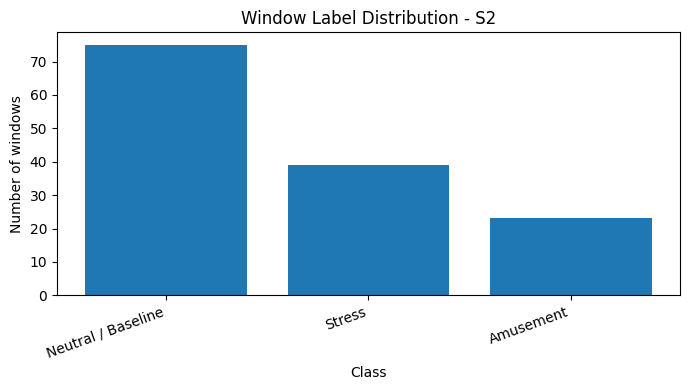

In [16]:
plt.figure(figsize=(7, 4))
plt.bar(window_label_distribution["label_name"], window_label_distribution["window_count"])
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.title(f"Window Label Distribution - {test_subject_id}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

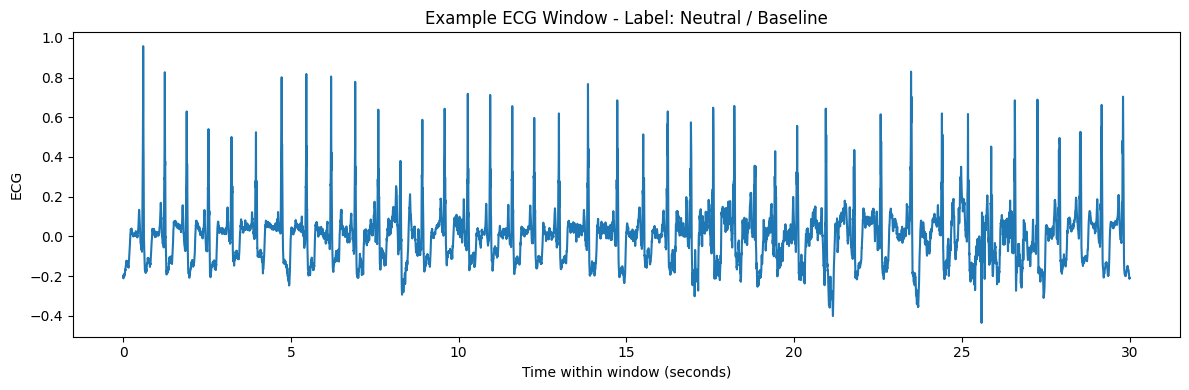

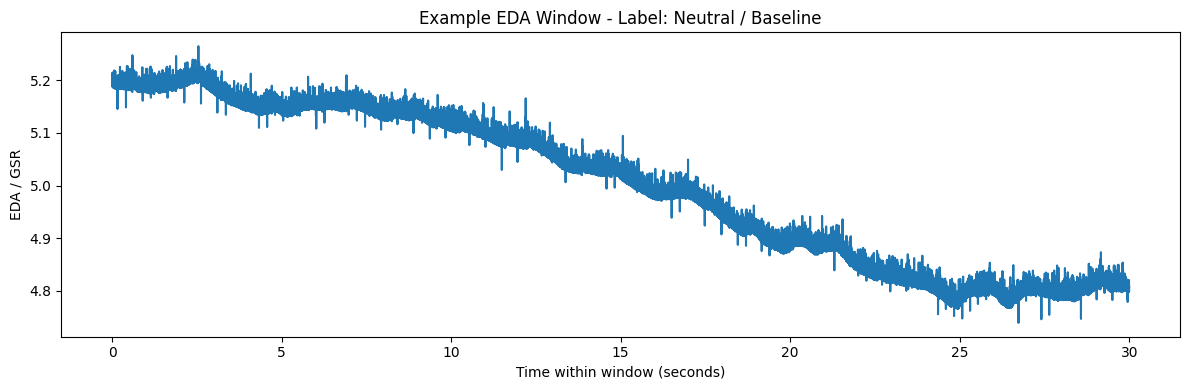

In [17]:
example_window_index = 0

example_window = X_test[example_window_index]
example_label = y_test[example_window_index]

time_axis = np.arange(WINDOW_SIZE_SAMPLES) / FS_CHEST

plt.figure(figsize=(12, 4))
plt.plot(time_axis, example_window[:, 0])
plt.xlabel("Time within window (seconds)")
plt.ylabel("ECG")
plt.title(f"Example ECG Window - Label: {LABEL_NAMES[example_label]}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_axis, example_window[:, 1])
plt.xlabel("Time within window (seconds)")
plt.ylabel("EDA / GSR")
plt.title(f"Example EDA Window - Label: {LABEL_NAMES[example_label]}")
plt.tight_layout()
plt.show()

In [18]:
all_X = []
all_y = []
all_metadata = []

for subject_folder in subject_folders:
    subject_id = subject_folder.name
    
    print("Processing:", subject_id)
    
    subject_data = load_subject_data(subject_id, RAW_DATA_DIR)
    subject_signals = extract_chest_signals(subject_data, SIGNAL_NAMES)
    subject_labels = subject_data["label"].reshape(-1)
    
    X_subject, y_subject, metadata_subject = create_windows_for_subject(
        subject_id=subject_id,
        signals=subject_signals,
        labels=subject_labels,
        window_size_samples=WINDOW_SIZE_SAMPLES,
        step_size_samples=STEP_SIZE_SAMPLES,
        target_labels=TARGET_LABELS,
        majority_threshold=0.80
    )
    
    print("  Windows created:", len(y_subject))
    
    all_X.append(X_subject)
    all_y.append(y_subject)
    all_metadata.append(metadata_subject)

Processing: S10
  Windows created: 149
Processing: S11
  Windows created: 144
Processing: S13
  Windows created: 145
Processing: S14
  Windows created: 145
Processing: S15
  Windows created: 145
Processing: S16
  Windows created: 143
Processing: S17
  Windows created: 149
Processing: S2
  Windows created: 137
Processing: S3
  Windows created: 138
Processing: S4
  Windows created: 141
Processing: S5
  Windows created: 144
Processing: S6
  Windows created: 143
Processing: S7
  Windows created: 143
Processing: S8
  Windows created: 142
Processing: S9
  Windows created: 143


In [19]:
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
metadata_all = pd.concat(all_metadata, ignore_index=True)

print("Final X shape:", X_all.shape)
print("Final y shape:", y_all.shape)
print("Final metadata shape:", metadata_all.shape)

Final X shape: (2151, 21000, 4)
Final y shape: (2151,)
Final metadata shape: (2151, 9)


In [20]:
total_label_distribution = metadata_all["label_name"].value_counts().reset_index()
total_label_distribution.columns = ["label_name", "window_count"]

total_label_distribution

,label_name,window_count
0,Neutral / Baseline,1154
1,Stress,644
2,Amusement,353


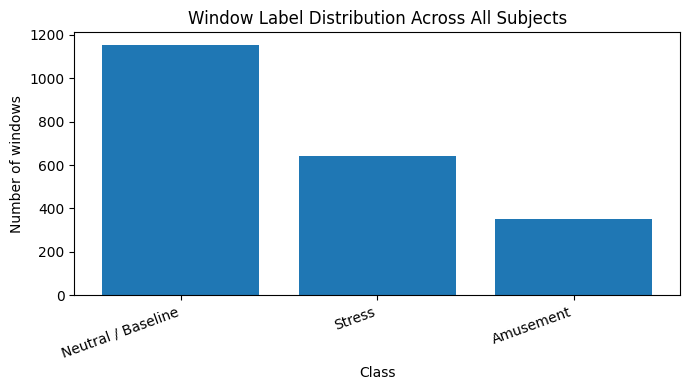

Saved figure to: ..\results\window_label_distribution.png


In [21]:
plt.figure(figsize=(7, 4))
plt.bar(total_label_distribution["label_name"], total_label_distribution["window_count"])
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.title("Window Label Distribution Across All Subjects")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "window_label_distribution.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [22]:
subject_window_counts = metadata_all.groupby("subject_id").size().reset_index(name="window_count")

subject_window_counts

,subject_id,window_count
0,S10,149
1,S11,144
2,S13,145
3,S14,145
4,S15,145
5,S16,143
6,S17,149
7,S2,137
8,S3,138
9,S4,141


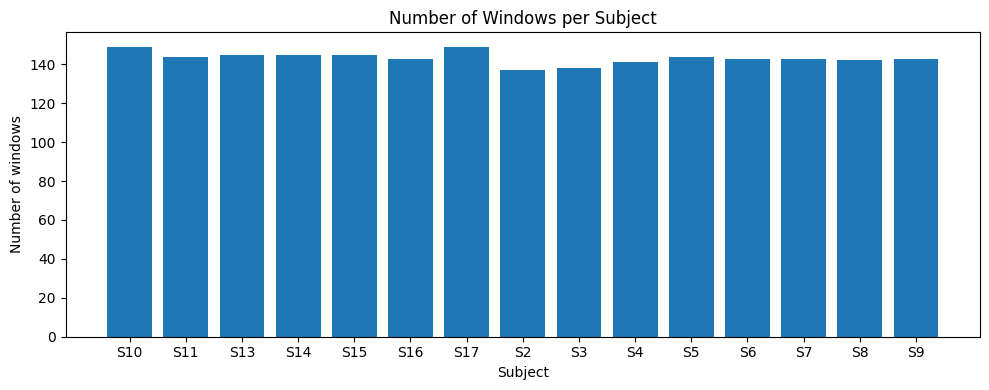

Saved figure to: ..\results\windows_per_subject.png


In [23]:
plt.figure(figsize=(10, 4))
plt.bar(subject_window_counts["subject_id"], subject_window_counts["window_count"])
plt.xlabel("Subject")
plt.ylabel("Number of windows")
plt.title("Number of Windows per Subject")
plt.tight_layout()

output_path = RESULTS_DIR / "windows_per_subject.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [24]:
np.save(PROCESSED_DATA_DIR / "X_windows.npy", X_all)
np.save(PROCESSED_DATA_DIR / "y_windows.npy", y_all)
metadata_all.to_csv(PROCESSED_DATA_DIR / "window_metadata.csv", index=False)

print("Saved X windows to:", PROCESSED_DATA_DIR / "X_windows.npy")
print("Saved y labels to:", PROCESSED_DATA_DIR / "y_windows.npy")
print("Saved metadata to:", PROCESSED_DATA_DIR / "window_metadata.csv")

Saved X windows to: ..\data\processed\X_windows.npy
Saved y labels to: ..\data\processed\y_windows.npy
Saved metadata to: ..\data\processed\window_metadata.csv


In [25]:
summary_rows = []

summary_rows.append({
    "item": "sampling_rate_hz",
    "value": FS_CHEST
})

summary_rows.append({
    "item": "window_size_seconds",
    "value": WINDOW_SIZE_SEC
})

summary_rows.append({
    "item": "overlap",
    "value": OVERLAP
})

summary_rows.append({
    "item": "step_size_seconds",
    "value": STEP_SIZE_SAMPLES / FS_CHEST
})

summary_rows.append({
    "item": "number_of_signals",
    "value": len(SIGNAL_NAMES)
})

summary_rows.append({
    "item": "signals_used",
    "value": ", ".join(SIGNAL_NAMES)
})

summary_rows.append({
    "item": "total_windows",
    "value": len(y_all)
})

for label_name, count in metadata_all["label_name"].value_counts().items():
    summary_rows.append({
        "item": f"windows_{label_name}",
        "value": count
    })

preprocessing_summary = pd.DataFrame(summary_rows)

preprocessing_summary.to_csv(RESULTS_DIR / "preprocessing_summary.csv", index=False)

preprocessing_summary

,item,value
0,sampling_rate_hz,700
1,window_size_seconds,30
2,overlap,0.5
3,step_size_seconds,15.0
4,number_of_signals,4
5,signals_used,"ECG, EDA, Resp, Temp"
6,total_windows,2151
7,windows_Neutral / Baseline,1154
8,windows_Stress,644
9,windows_Amusement,353
